In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('data.csv')

🧠 Section 1: Dataset Understanding 

1. What is the total number of rows and columns in the dataset? 

2. What are the data types of each feature? 

3. Which features are categorical and which are numerical? 

4. Are there any missing values? If yes, in which columns? 

5. Are there any duplicate records present? 

## 1. Data Understadning

In [4]:
print("Total number of rows: ", data.shape[0])
print("Total number of columns: ", data.shape[1])

Total number of rows:  1705
Total number of columns:  11


In [7]:
print("data types:\n",data.dtypes)

data types:
 Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score             float64
Overall_Impact                   object
dtype: object


In [11]:
numerical_cols = data.select_dtypes(include = ["int64", "float64"]).columns
categorical_cols = data.select_dtypes(include = ["object"]).columns
print("numerical columns: ", numerical_cols)
print("==="*400)
print("categorical columns: ", categorical_cols)

numerical columns:  Index(['Student_ID', 'Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score'],
      dtype='object')
categorical columns:  Index(['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Overall_Impact'],
      dtype='object')


In [12]:
## missing values
print("Missing values in each column:\n", data.isnull().sum())

Missing values in each column:
 Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64


In [13]:
print("Duplicate rows: ", data.duplicated().sum())

Duplicate rows:  0


##### The data is clean we have done preprocessing earlier in data_preprocessing notebook.

## Section 3: Univariate Analysis 

1. What is the distribution of Avg_Daily_Usage_Hours? 
2. What is the distribution of Mental_Health_Score? 
3. What is the distribution of Sleep_Hours_Per_Night? 
4. Which social media platform is most frequently used? 
4. What is the gender distribution in the dataset? 

In [15]:
def distribution_plot(column):
    plt.figure(figsize=(12,6))
    sns.histplot(data[column], bins=30, kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

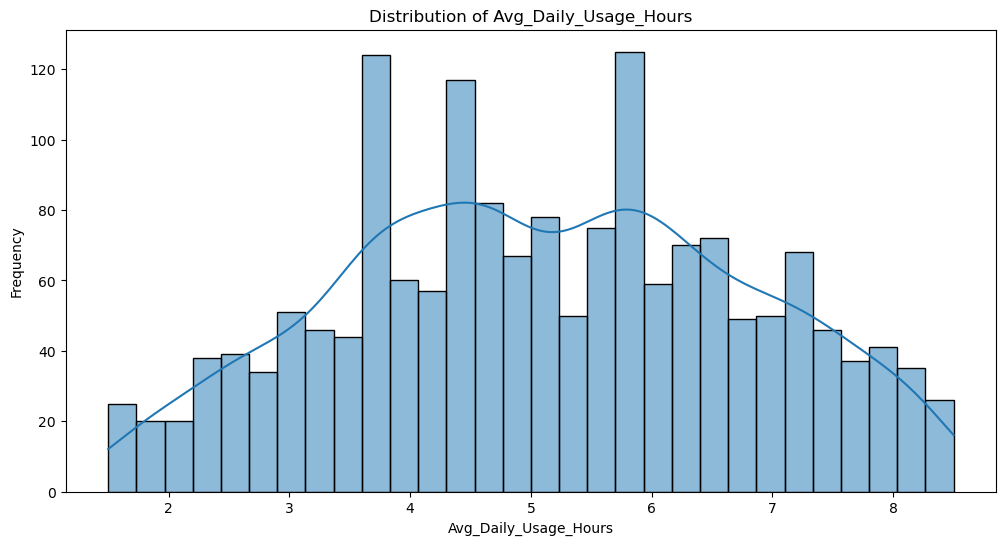

In [16]:
distribution_plot('Avg_Daily_Usage_Hours')

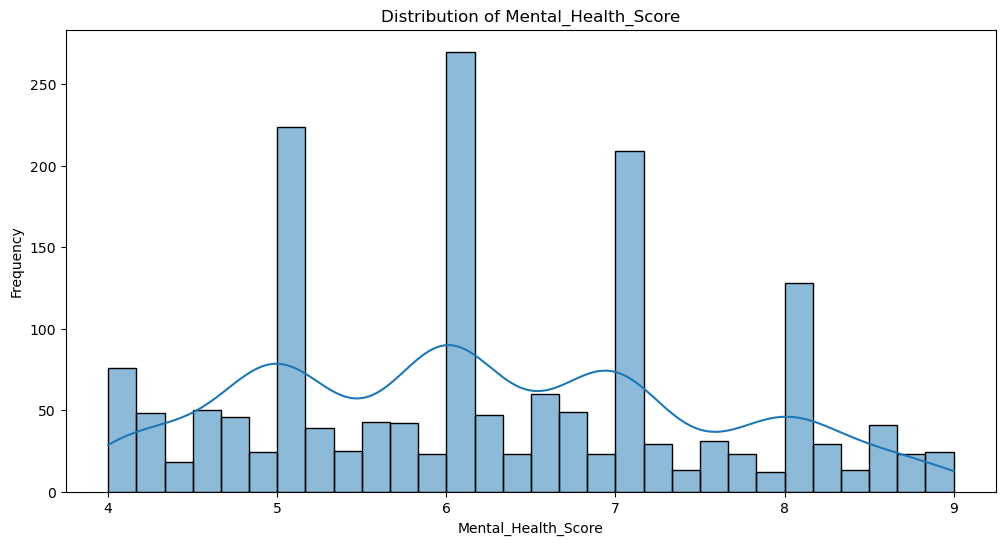

In [17]:
distribution_plot("Mental_Health_Score")

## H-1: - Possibility is this that those who spend more time on social media may have less mental score.

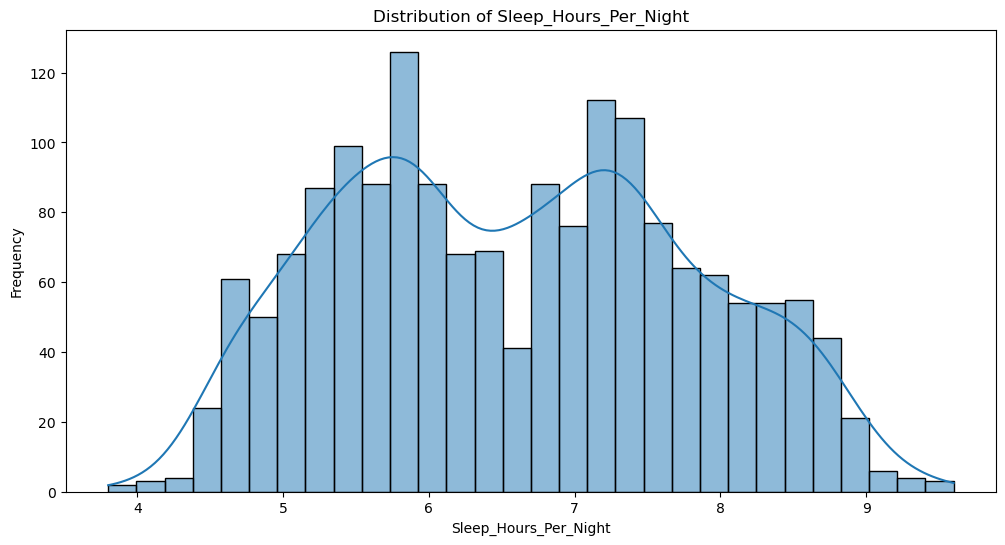

In [18]:
distribution_plot("Sleep_Hours_Per_Night")

In [20]:
## table to understand average of each metrics
num_col = data.select_dtypes(include = ["int64", "float64"]).columns
for i in num_col:
    print(f"Average {i}: ", data[i].mean())

Average Student_ID:  439.51026392961876
Average Age:  20.84809384164223
Average Avg_Daily_Usage_Hours:  5.103636363636364
Average Sleep_Hours_Per_Night:  6.598709677419355
Average Mental_Health_Score:  6.215131964809384


## H-2: - It possbile that people having less sleep and more social media have measure depreciation in mental health score.



In [21]:
## most used platform
print("Most used platform: ", data['Most_Used_Platform'].mode()[0])

Most used platform:  Instagram


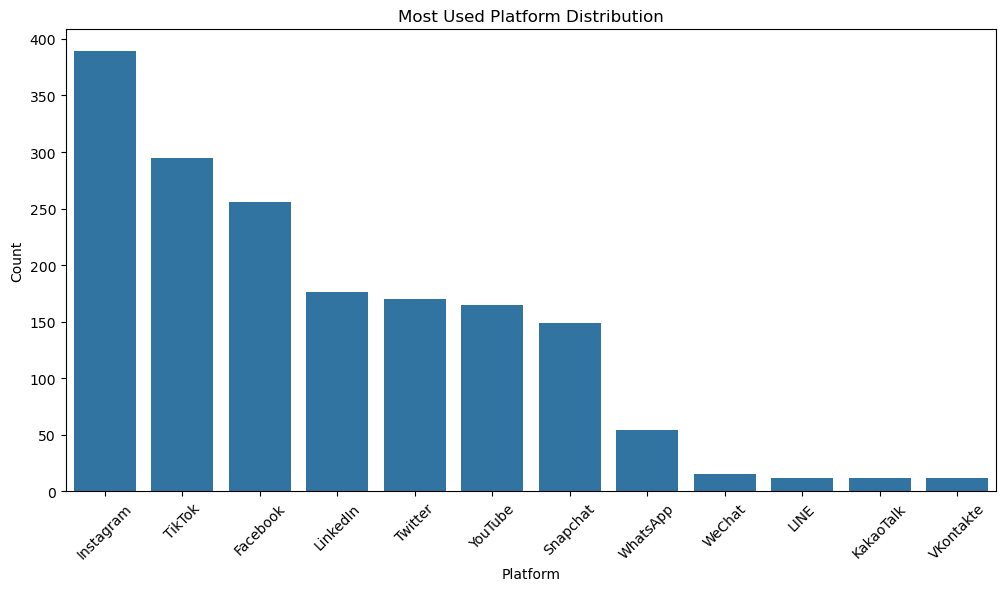

In [25]:
most = data['Most_Used_Platform'].value_counts().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(y=most['count'], x=most['Most_Used_Platform'])
plt.title('Most Used Platform Distribution')
plt.xlabel('Platform')      
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [23]:
most

,Most_Used_Platform,count
0,Instagram,389
1,TikTok,295
2,Facebook,256
3,LinkedIn,176
4,Twitter,170
5,YouTube,165
6,Snapchat,149
7,WhatsApp,54
8,WeChat,15
9,LINE,12


In [31]:
data['Most_Used_Platform'].value_counts().index[0]

'Instagram'

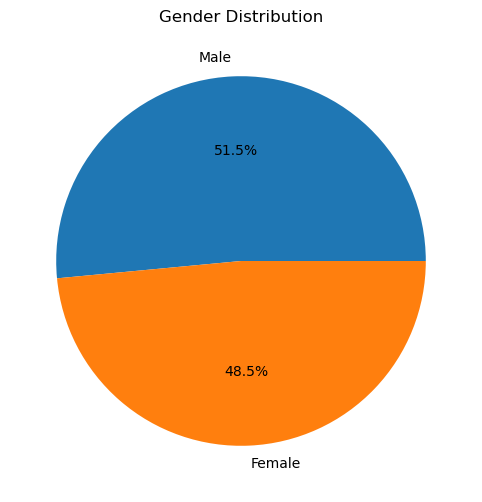

In [35]:
plt.figure(figsize=(12,6))
plt.pie(data["Gender"].value_counts(), labels=data['Gender'].value_counts().index, autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

🔗 Section 4: Bivariate Analysis 

1. Is there a relationship between social media usage and mental health score? 

2. How does social media usage affect sleep duration? 

3. Do students who report academic impact have higher usage? 

4. Is there any difference in mental health scores across genders? 

5. Does age influence social media usage? 

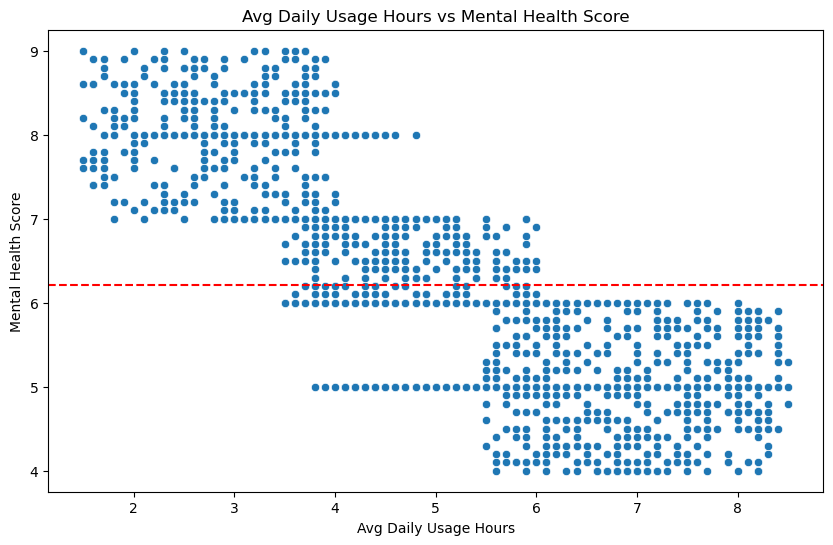

In [39]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', data=data)
plt.axhline(y=data['Mental_Health_Score'].mean(), color='r', linestyle='--', label='Average Mental Health Score')
plt.title('Avg Daily Usage Hours vs Mental Health Score')
plt.xlabel('Avg Daily Usage Hours')
plt.ylabel('Mental Health Score')
plt.show()

Their is direct relation between the avg_daily_usage and mental health which suggestes that those who use social media more have less mental score.

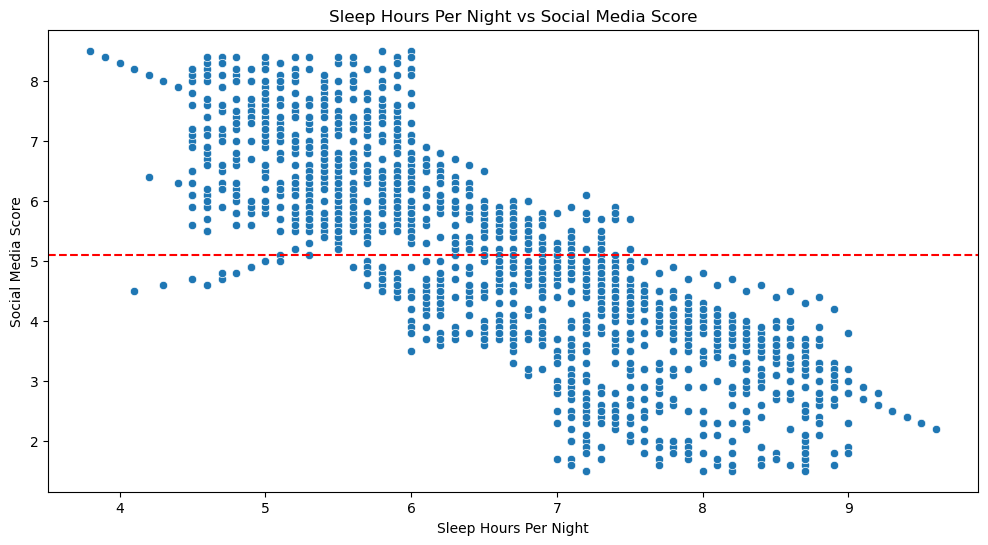

In [43]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Avg_Daily_Usage_Hours', data=data)
plt.axhline(y=data['Avg_Daily_Usage_Hours'].mean(), color='r', linestyle='--', label='Average Social Media Score')
plt.title('Sleep Hours Per Night vs Social Media Score')
plt.xlabel('Sleep Hours Per Night')
plt.ylabel('Social Media Score')
plt.show()

Their is direct relation between the avg_daily_usage and sleep which suggestes that those who use social media more have less sleeping hours.

In [44]:
data.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


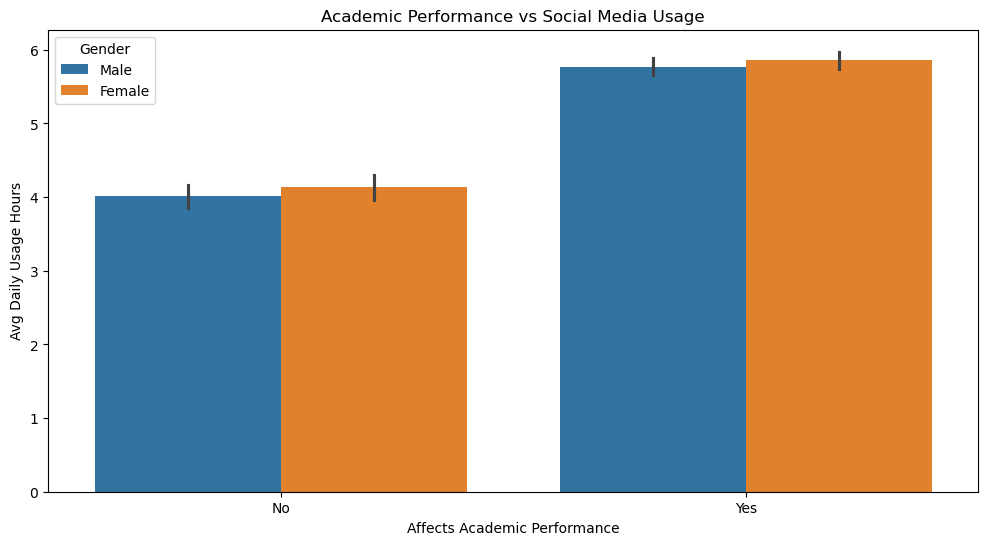

In [46]:
plt.figure(figsize=(12,6))
sns.barplot(x = "Affects_Academic_Performance", y = "Avg_Daily_Usage_Hours", data=data, hue = "Gender")
plt.title('Academic Performance vs Social Media Usage')
plt.xlabel('Affects Academic Performance')
plt.ylabel('Avg Daily Usage Hours')
plt.show()

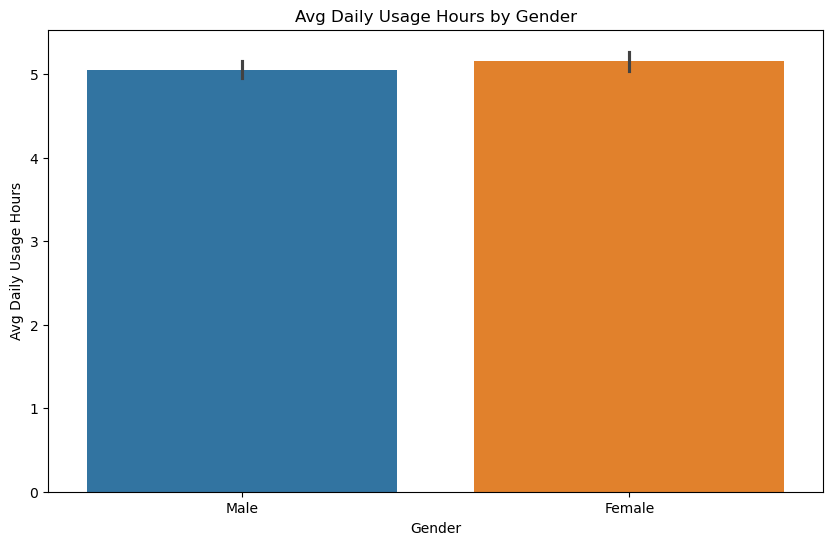

In [47]:
plt.figure(figsize=(10,6))
sns.barplot(y="Avg_Daily_Usage_Hours", x = "Gender", data=data, hue = "Gender")
plt.title('Avg Daily Usage Hours by Gender')
plt.xlabel('Gender')
plt.ylabel('Avg Daily Usage Hours')
plt.show()

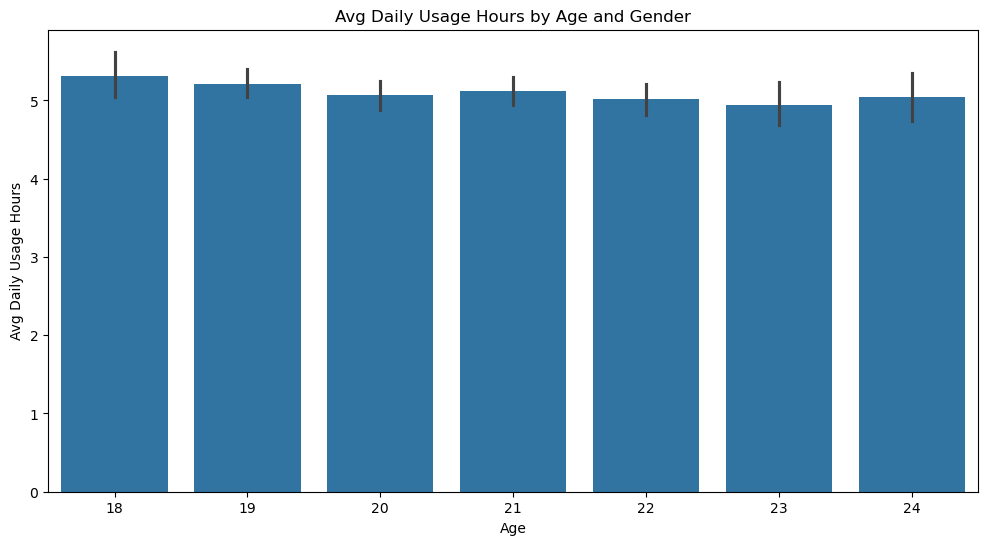

In [49]:
plt.figure(figsize=(12,6))
sns.barplot(x = "Age", y = "Avg_Daily_Usage_Hours", data=data)
plt.title('Avg Daily Usage Hours by Age and Gender')
plt.xlabel('Age')   
plt.ylabel('Avg Daily Usage Hours')
plt.show()  

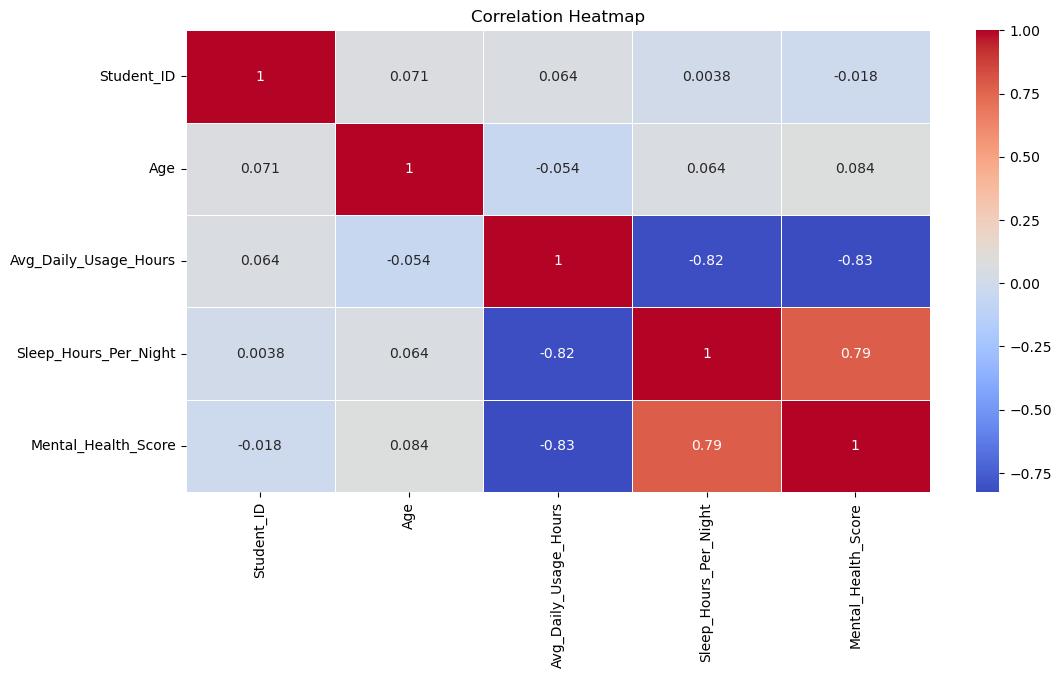

In [52]:
## correlation 
plt.figure(figsize=(12,6))
sns.heatmap(data.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

-0.5<x<0.5 -----> Weak correlation
x>0.8 and x<-0.8 ----> Strong correlation

In [53]:
## 
data.head()


,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative
